# Actor-Critic and PPO
### From value functions to the algorithm that makes RLHF work

This notebook builds Actor-Critic from first principles, arriving at PPO as the natural solution to the instability problems that vanilla Actor-Critic exposes. At the end, the connection back to the RLHF notebook is explicit.

Everything is implemented in pure numpy. The environment is a CartPole simulator — a pole balanced on a cart — built from scratch so every number is inspectable.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams
from collections import deque

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'
YELLOW  = '#d29922'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("Ready.")

Ready.


## Part 1 — The reinforcement learning setup

Before building any networks, I need to be precise about the problem structure.

Reinforcement learning has five moving parts:

| Symbol | Name | What it is |
|--------|------|------------|
| $s_t$ | State | Everything the agent can observe at time $t$ |
| $a_t$ | Action | What the agent does in response |
| $r_t$ | Reward | Scalar feedback from the environment |
| $\pi(a|s)$ | Policy | Probability distribution over actions given state |
| $\gamma$ | Discount factor | How much to value future rewards vs immediate ones |

The agent's goal is to find a policy $\pi$ that maximises **expected cumulative discounted reward**:

$$J(\pi) = \mathbb{E}_{\tau \sim \pi} \left[ \sum_{t=0}^{T} \gamma^t r_t \right]$$

Where $\tau = (s_0, a_0, r_0, s_1, a_1, r_1, ...)$ is a **trajectory** — one complete run through the environment.

The discount factor $\gamma \in [0, 1)$ makes the sum finite and encodes a preference for sooner rewards. $\gamma = 0.99$ means a reward one step away is worth 0.99× a reward now; 100 steps away is worth $0.99^{100} \approx 0.37$× a reward now.

## Part 2 — The CartPole environment

I need an environment to train on. CartPole is the right choice here: simple enough to implement in 50 lines, complex enough to require a real learning algorithm.

**The task**: a pole is attached to a cart that moves along a frictionless track. At each step, apply a force left or right. The episode ends when the pole falls past 12° or the cart leaves the track. Survive as long as possible.

**State**: 4 numbers — cart position, cart velocity, pole angle, pole angular velocity.

**Actions**: 2 — push left (0) or push right (1).

**Reward**: +1 for every timestep the pole stays upright.

In [2]:
class CartPole:
    """
    CartPole physics from scratch.
    State: [cart_pos, cart_vel, pole_angle, pole_angular_vel]
    Actions: 0=push left, 1=push right
    """
    # Physical constants
    GRAVITY     = 9.8
    CART_MASS   = 1.0
    POLE_MASS   = 0.1
    POLE_HALF_L = 0.5
    FORCE_MAG   = 10.0
    DT          = 0.02       # timestep in seconds
    TOTAL_MASS  = CART_MASS + POLE_MASS

    # Episode termination thresholds
    ANGLE_LIMIT = 12 * np.pi / 180   # 12 degrees
    POS_LIMIT   = 2.4
    MAX_STEPS   = 500

    def reset(self):
        # Small random initial state
        self.state = np.random.uniform(-0.05, 0.05, 4)
        self.steps = 0
        return self.state.copy()

    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        force = self.FORCE_MAG if action == 1 else -self.FORCE_MAG

        # Equations of motion (Florian 2007)
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        ml    = self.POLE_MASS * self.POLE_HALF_L

        temp         = (force + ml * theta_dot**2 * sin_t) / self.TOTAL_MASS
        theta_acc    = (self.GRAVITY * sin_t - cos_t * temp) / \
                       (self.POLE_HALF_L * (4/3 - self.POLE_MASS * cos_t**2 / self.TOTAL_MASS))
        x_acc        = temp - ml * theta_acc * cos_t / self.TOTAL_MASS

        # Euler integration
        x         += self.DT * x_dot
        x_dot     += self.DT * x_acc
        theta     += self.DT * theta_dot
        theta_dot += self.DT * theta_acc

        self.state = np.array([x, x_dot, theta, theta_dot])
        self.steps += 1

        done = (abs(x)     > self.POS_LIMIT or
                abs(theta) > self.ANGLE_LIMIT or
                self.steps >= self.MAX_STEPS)

        reward = 1.0 if not done or self.steps >= self.MAX_STEPS else 0.0
        return self.state.copy(), reward, done


# Quick sanity check — random policy
env = CartPole()
state = env.reset()
total_reward = 0
for _ in range(500):
    action = np.random.randint(2)
    state, reward, done = env.step(action)
    total_reward += reward
    if done:
        break

print(f"Random policy survived {int(total_reward)} steps.")
print(f"State at termination: {state.round(4)}")
print(f"  [cart_pos={state[0]:.3f}, cart_vel={state[1]:.3f}, "
      f"pole_angle={np.degrees(state[2]):.2f}°, pole_vel={state[3]:.3f}]")
print(f"\nA random policy typically lasts 10-20 steps. A trained policy reaches 500.")

Random policy survived 13 steps.
State at termination: [-0.1067 -0.363   0.2163  1.0108]
  [cart_pos=-0.107, cart_vel=-0.363, pole_angle=12.39°, pole_vel=1.011]

A random policy typically lasts 10-20 steps. A trained policy reaches 500.


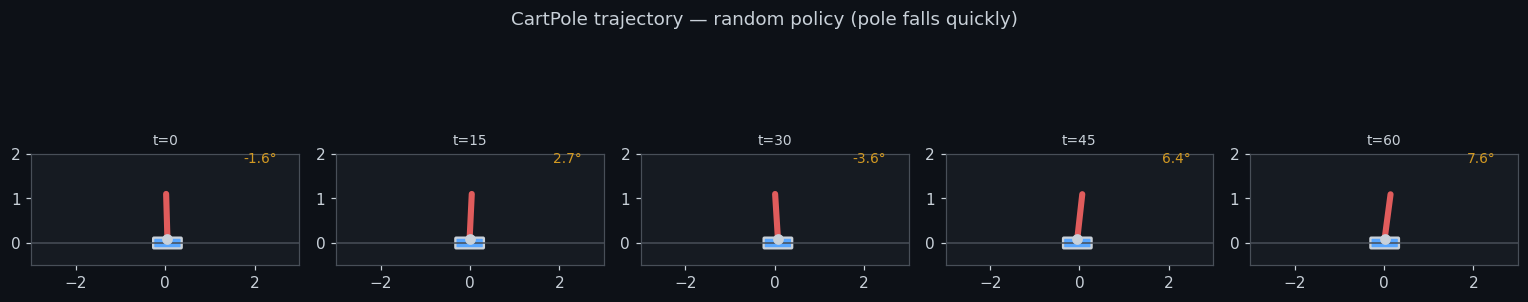

In [3]:
# ── Visualise the environment ──────────────────────────────────────────────────
def render_cartpole(state, ax, title=''):
    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.5, 2.0)
    ax.set_aspect('equal')
    ax.set_title(title, color=TEXT, fontsize=9)
    ax.axhline(0, color=MUTED, linewidth=1)

    x, _, theta, _ = state

    # Cart
    cart = patches.FancyBboxPatch((x - 0.3, -0.1), 0.6, 0.2,
                                   boxstyle='round,pad=0.02',
                                   facecolor=BLUE, edgecolor=TEXT, linewidth=1.5)
    ax.add_patch(cart)

    # Pole
    pole_len = 1.0
    px = x + pole_len * np.sin(theta)
    py = pole_len * np.cos(theta)
    ax.plot([x, px], [0.1, 0.1 + py], color=ACCENT, linewidth=4, solid_capstyle='round')
    ax.plot(x, 0.1, 'o', color=TEXT, markersize=6)

    # Angle indicator
    ax.text(2.5, 1.8, f'{np.degrees(theta):.1f}°', color=YELLOW, fontsize=9, ha='right')

# Record a trajectory
env = CartPole()
state = env.reset()
trajectory = [state.copy()]
for _ in range(60):
    action = np.random.randint(2)
    state, _, done = env.step(action)
    trajectory.append(state.copy())
    if done:
        break

# Show 5 frames
frames = np.linspace(0, len(trajectory)-1, 5, dtype=int)
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, idx in zip(axes, frames):
    render_cartpole(trajectory[idx], ax, title=f't={idx}')

fig.suptitle('CartPole trajectory — random policy (pole falls quickly)', color=TEXT, y=1.05)
plt.tight_layout()
plt.show()

## Part 3 — The value function: what the critic learns

The central concept in Actor-Critic is the **value function** $V^\pi(s)$.

$$V^\pi(s) = \mathbb{E}_{\tau \sim \pi} \left[ \sum_{t=0}^{T} \gamma^t r_t \;\ \bigg|\;\ s_0 = s \right]$$

This is the **expected total discounted reward** you'll get if you start in state $s$ and follow policy $\pi$ from there.

It's a prediction: *given where I am right now, how much reward do I expect to accumulate from here?*

In CartPole:
- State: pole nearly vertical, cart near centre → high value (likely to survive long)
- State: pole at 10°, cart near edge → low value (about to terminate)

### Why does the critic need to exist?

To train the actor (policy), we need to know whether each action was **better or worse than expected**. That's the **advantage**:

$$A^\pi(s_t, a_t) = Q^\pi(s_t, a_t) - V^\pi(s_t)$$

Where $Q^\pi(s, a)$ is the expected return starting from state $s$, taking action $a$, then following $\pi$.

We don't learn $Q$ separately. Instead, after observing the actual next state $s_{t+1}$ and reward $r_t$, we estimate the advantage as:

$$\hat{A}_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

This is the **TD error** (Temporal Difference error). It answers: *was the actual reward plus future value estimate better or worse than what the critic predicted for this state?*

- $\hat{A}_t > 0$: this action led to a better-than-expected outcome → increase its probability
- $\hat{A}_t < 0$: this action led to a worse-than-expected outcome → decrease its probability
- $\hat{A}_t \approx 0$: about as expected → no strong update signal

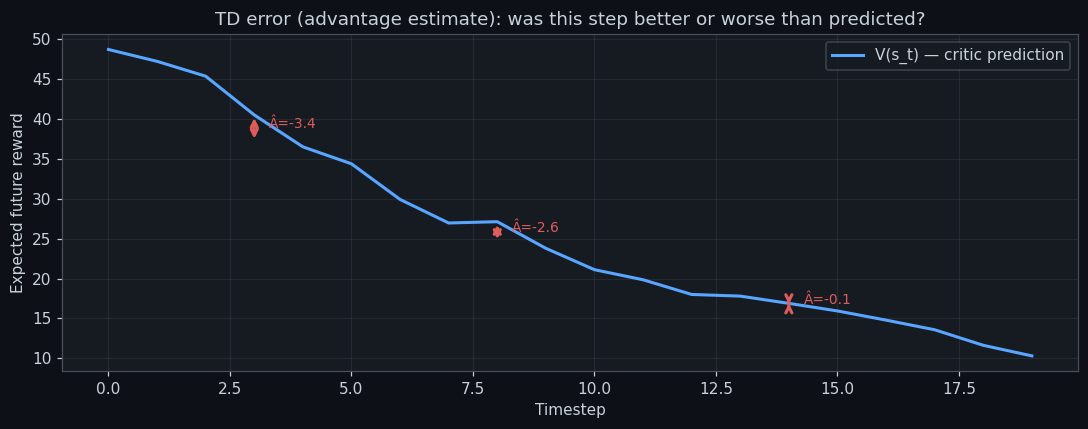

Green arrows: r_t + γV(s_{t+1}) > V(s_t) — better than expected → increase action prob
Red arrows:   r_t + γV(s_{t+1}) < V(s_t) — worse than expected  → decrease action prob


In [4]:
# ── Visualise the advantage concept ───────────────────────────────────────────
# Show what the TD error means geometrically

fig, ax = plt.subplots(figsize=(10, 4))

t = np.arange(20)
# Simulated value estimates over a trajectory (declining as pole gets wobbly)
V_vals = 50 * np.exp(-0.08 * t) + np.random.normal(0, 1, 20)
rewards = np.ones(20)
gamma = 0.99

ax.plot(t, V_vals, color=BLUE, linewidth=2, label='V(s_t) — critic prediction')

# TD errors at a few points
highlight = [3, 8, 14]
for h in highlight:
    td_error = rewards[h] + gamma * V_vals[h+1] - V_vals[h]
    color = GREEN if td_error > 0 else ACCENT
    ax.annotate('',
        xy=(h, rewards[h] + gamma * V_vals[h+1]),
        xytext=(h, V_vals[h]),
        arrowprops=dict(arrowstyle='<->', color=color, lw=2))
    ax.text(h + 0.3, (V_vals[h] + rewards[h] + gamma * V_vals[h+1]) / 2,
            f'Â={td_error:+.1f}', color=color, fontsize=9)

ax.set_xlabel('Timestep')
ax.set_ylabel('Expected future reward')
ax.set_title('TD error (advantage estimate): was this step better or worse than predicted?', color=TEXT)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print("Green arrows: r_t + γV(s_{t+1}) > V(s_t) — better than expected → increase action prob")
print("Red arrows:   r_t + γV(s_{t+1}) < V(s_t) — worse than expected  → decrease action prob")

## Part 4 — The policy gradient: how the actor learns

The actor is a network that outputs action probabilities. We need a gradient to update it.

The **Policy Gradient Theorem** tells us the gradient of $J(\pi_\theta)$ with respect to the policy parameters:

$$\nabla_\theta J(\pi_\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot \hat{A}_t \right]$$

Breaking this down:

- $\nabla_\theta \log \pi_\theta(a_t|s_t)$ — the **score function**: how does the log-probability of the chosen action change as we adjust the parameters? This tells us which direction to push the parameters to make $a_t$ more or less likely.

- $\hat{A}_t$ — the **advantage**: should we push in that direction or away from it? If the action was better than expected (positive advantage), increase its probability. If worse (negative advantage), decrease it.

The elegant part: we never need to differentiate through the environment. We just need trajectories, rewards, and the critic's value estimates. The environment can be a black box — or in the RLHF case, a human preference.

### The actor loss

In practice we do gradient *descent*, so we minimise the negative of the objective:

$$\mathcal{L}_{actor} = -\mathbb{E}_t \left[ \log \pi_\theta(a_t|s_t) \cdot \hat{A}_t \right]$$

### The critic loss

The critic minimises the squared TD error — it's trying to make its value predictions accurate:

$$\mathcal{L}_{critic} = \mathbb{E}_t \left[ \left( r_t + \gamma V(s_{t+1}) - V(s_t) \right)^2 \right] = \mathbb{E}_t\left[\hat{A}_t^2\right]$$

In [5]:
# ── Actor-Critic networks ──────────────────────────────────────────────────────

def sigmoid(x):   return 1 / (1 + np.exp(-np.clip(x, -20, 20)))
def relu(x):      return np.maximum(0, x)
def relu_grad(x): return (x > 0).astype(float)

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

class ActorCritic:
    """
    Shared trunk, separate heads.
    Input: 4-dim state
    Trunk: one hidden layer (ReLU)
    Actor head: 2 outputs (action logits) → softmax → action probabilities
    Critic head: 1 output (scalar value estimate)
    """
    def __init__(self, n_states=4, n_actions=2, hidden=64, lr=3e-3, gamma=0.99):
        self.gamma    = gamma
        self.lr       = lr
        self.n_actions = n_actions

        scale = 0.1
        # Shared trunk
        self.W1 = np.random.randn(n_states, hidden) * scale
        self.b1 = np.zeros(hidden)

        # Actor head
        self.W_a = np.random.randn(hidden, n_actions) * scale
        self.b_a = np.zeros(n_actions)

        # Critic head
        self.W_c = np.random.randn(hidden, 1) * scale
        self.b_c = np.zeros(1)

    def forward(self, state):
        """Returns (action_probs, value, hidden_activations)."""
        h     = relu(state @ self.W1 + self.b1)
        logits = h @ self.W_a + self.b_a
        probs  = softmax(logits)
        value  = float(h @ self.W_c + self.b_c)
        return probs, value, h

    def select_action(self, state):
        """Sample an action from the policy."""
        probs, value, _ = self.forward(state)
        action = np.random.choice(self.n_actions, p=probs)
        return action, probs[action], value

    def update(self, state, action, reward, next_state, done):
        """
        One-step Actor-Critic update.
        Returns the TD error (advantage estimate).
        """
        probs, V_s, h = self.forward(state)
        _, V_next, _  = self.forward(next_state)

        # TD error / advantage estimate
        target    = reward + self.gamma * V_next * (1 - done)
        advantage = target - V_s

        # ── Critic update (minimise squared TD error) ──────────────────────────
        dV    = -2 * advantage                    # d(advantage²)/dV_s = -2A
        dW_c  = h.reshape(-1, 1) * dV
        db_c  = np.array([dV])
        dh_c  = (dV * self.W_c).flatten()

        # ── Actor update (maximise log π(a|s) · advantage) ────────────────────
        # Gradient of log π w.r.t. logits: one-hot(action) - probs
        d_logits      = probs.copy()
        d_logits[action] -= 1.0
        d_logits      *= -advantage               # scale by advantage, negate for ascent→descent

        dW_a = h.reshape(-1, 1) * d_logits.reshape(1, -1)
        db_a = d_logits
        dh_a = (d_logits @ self.W_a.T)

        # ── Shared trunk gradient: sum of actor and critic contributions ────────
        dh      = (dh_a + dh_c) * relu_grad(state @ self.W1 + self.b1)
        dW1     = state.reshape(-1, 1) * dh.reshape(1, -1)
        db1     = dh

        # ── Gradient descent ───────────────────────────────────────────────────
        for param, grad in [
            ('W1', dW1), ('b1', db1),
            ('W_a', dW_a), ('b_a', db_a),
            ('W_c', dW_c), ('b_c', db_c),
        ]:
            setattr(self, param, getattr(self, param) - self.lr * grad)

        return float(advantage)

print("ActorCritic defined.")
ac = ActorCritic()
state = env.reset()
probs, value, _ = ac.forward(state)
print(f"Initial action probs: {probs.round(4)}  (should be near [0.5, 0.5])")
print(f"Initial value estimate: {value:.4f}  (random; will calibrate during training)")

ActorCritic defined.
Initial action probs: [0.4986 0.5014]  (should be near [0.5, 0.5])
Initial value estimate: -0.0018  (random; will calibrate during training)


## Part 5 — Training vanilla Actor-Critic

In [6]:
def train_episode(agent, env):
    """Run one episode, updating the agent at each step. Returns episode reward."""
    state     = env.reset()
    total_r   = 0
    advantages = []

    for _ in range(env.MAX_STEPS):
        action, _, _ = agent.select_action(state)
        next_state, reward, done = env.step(action)

        advantage = agent.update(state, action, reward, next_state, done)
        advantages.append(advantage)

        total_r += reward
        state    = next_state
        if done:
            break

    return total_r, advantages


np.random.seed(1)
ac  = ActorCritic(hidden=64, lr=3e-3, gamma=0.99)
env = CartPole()

N_EPISODES = 600
rewards_history = []
all_advantages  = []

for ep in range(N_EPISODES):
    ep_reward, ep_advantages = train_episode(ac, env)
    rewards_history.append(ep_reward)
    all_advantages.extend(ep_advantages)

    if (ep + 1) % 100 == 0:
        recent = np.mean(rewards_history[-50:])
        print(f"Episode {ep+1:4d} | last 50 mean: {recent:6.1f} steps")

Episode  100 | last 50 mean:    8.7 steps
Episode  200 | last 50 mean:    8.4 steps
Episode  300 | last 50 mean:    8.3 steps
Episode  400 | last 50 mean:    8.4 steps
Episode  500 | last 50 mean:    8.4 steps
Episode  600 | last 50 mean:    8.2 steps


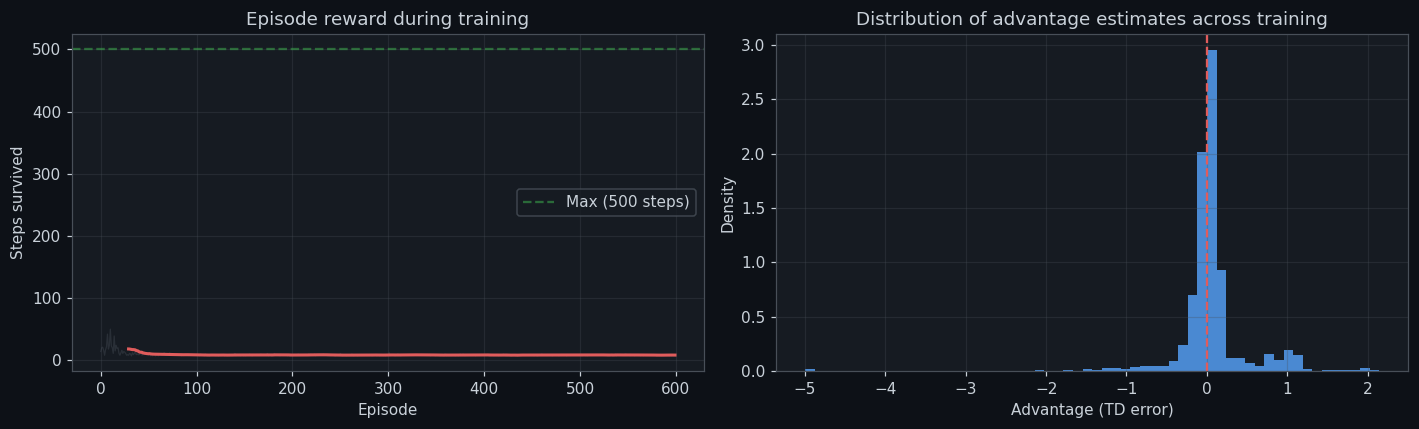

Final 50-episode mean: 8.2 steps
Advantage mean: 0.0543  (should be near 0 when critic is calibrated)
Advantage std:  0.5346  (variance in the gradient signal)


In [7]:
# ── Training curve ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(rewards_history, color=MUTED, alpha=0.4, linewidth=0.8)
window = 30
smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
ax.plot(np.arange(window-1, len(rewards_history)), smooth, color=ACCENT, linewidth=2)
ax.axhline(500, color=GREEN, linestyle='--', alpha=0.5, label='Max (500 steps)')
ax.set_title('Episode reward during training', color=TEXT)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps survived')
ax.legend()
ax.grid(True)

ax = axes[1]
# Advantage distribution over training — should centre around 0
ax.hist(np.clip(all_advantages, -5, 5), bins=60, color=BLUE, alpha=0.8, density=True)
ax.axvline(0, color=ACCENT, linestyle='--', linewidth=1.5)
ax.set_title('Distribution of advantage estimates across training', color=TEXT)
ax.set_xlabel('Advantage (TD error)')
ax.set_ylabel('Density')
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Final 50-episode mean: {np.mean(rewards_history[-50:]):.1f} steps")
print(f"Advantage mean: {np.mean(all_advantages):.4f}  (should be near 0 when critic is calibrated)")
print(f"Advantage std:  {np.std(all_advantages):.4f}  (variance in the gradient signal)")

## Part 6 — What vanilla Actor-Critic gets wrong

The training curve probably shows something familiar: noisy improvement, possible collapses, inconsistent performance. This is the characteristic signature of vanilla policy gradients, and it comes from two structural problems.

### Problem 1 — High gradient variance

Each update uses a single trajectory sample to estimate the expected gradient. The Policy Gradient Theorem guarantees this is an *unbiased* estimator — on average, it points the right direction. But the variance can be enormous.

One bad episode (pole falls immediately, returns a large negative advantage) produces a huge gradient that might undo many good updates. One lucky episode (pole happens to stay up due to random action, not good policy) produces a large positive gradient that overcredits mediocre decisions.

The advantage estimate $\hat{A}_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ reduces variance compared to using raw returns — but only as much as the critic is accurate. Early in training, the critic is bad, so the advantage estimates are noisy.

### Problem 2 — Destructive updates

Policy gradient has no constraint on step size. A large gradient from a noisy estimate can push the policy into a bad region — and once there, the policy generates worse data, which produces worse gradient estimates, which produce worse updates. This is a death spiral.

In practice this manifests as the **collapse** visible in many training curves: reward climbs, then crashes back to near-zero, and the agent has to relearn from scratch.

Both problems have the same root: **we're using stale policy data to make updates, with no control over how far we move**.

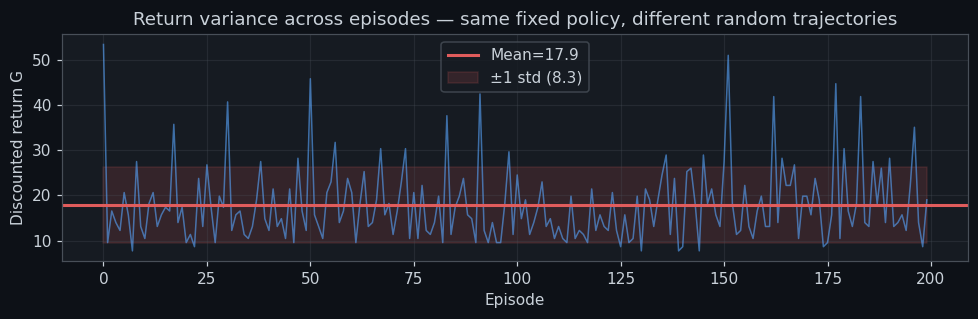

Coefficient of variation: 0.47
The gradient signal varies by this proportion across episodes — same policy, same task.
This is the noise the actor is trying to learn through.


In [8]:
# ── Demonstrate gradient variance ─────────────────────────────────────────────
# Run 20 independent episodes with a fixed policy, compute the gradient
# each time, and show how much it varies.

np.random.seed(5)
fixed_agent = ActorCritic(hidden=32, lr=0)
env2 = CartPole()

episode_returns = []
for _ in range(200):
    state = env2.reset()
    G = 0
    gamma_t = 1.0
    for _ in range(500):
        action, _, _ = fixed_agent.select_action(state)
        state, r, done = env2.step(action)
        G += gamma_t * r
        gamma_t *= 0.99
        if done:
            break
    episode_returns.append(G)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(episode_returns, color=BLUE, alpha=0.6, linewidth=1)
ax.axhline(np.mean(episode_returns), color=ACCENT, linewidth=2, label=f'Mean={np.mean(episode_returns):.1f}')
ax.fill_between(range(len(episode_returns)),
                np.mean(episode_returns) - np.std(episode_returns),
                np.mean(episode_returns) + np.std(episode_returns),
                color=ACCENT, alpha=0.15, label=f'±1 std ({np.std(episode_returns):.1f})')
ax.set_title('Return variance across episodes — same fixed policy, different random trajectories', color=TEXT)
ax.set_xlabel('Episode')
ax.set_ylabel('Discounted return G')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

cv = np.std(episode_returns) / (np.mean(episode_returns) + 1e-6)
print(f"Coefficient of variation: {cv:.2f}")
print(f"The gradient signal varies by this proportion across episodes — same policy, same task.")
print(f"This is the noise the actor is trying to learn through.")

## Part 7 — PPO: fixing both problems

PPO (Schulman et al., 2017) addresses both variance and destructive updates with one mechanism: the **clipped surrogate objective**.

### The importance sampling ratio

To reduce variance, we want to reuse data from previous policy versions rather than discarding it after one update. But if we've updated the policy, the old data was collected under a *different* distribution.

**Importance sampling** corrects for this. If data was collected under old policy $\pi_{old}$ but we want gradient estimates for new policy $\pi_\theta$, we weight each sample by:

$$\rho_t = \frac{\pi_\theta(a_t|s_t)}{\pi_{old}(a_t|s_t)}$$

If the new policy assigns higher probability to this action than the old one did, $\rho_t > 1$. If lower, $\rho_t < 1$.

The importance-sampled objective becomes:

$$\mathcal{L}^{IS}(\theta) = \mathbb{E}_t \left[ \rho_t(\theta) \cdot \hat{A}_t \right]$$

This works as long as $\pi_\theta$ and $\pi_{old}$ are similar. If they diverge, the weights become extreme and the estimate is unreliable.

### The clip

PPO limits how much $\rho_t$ can deviate from 1 by **clipping** it:

$$\mathcal{L}^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left( \rho_t \hat{A}_t,\ \text{clip}(\rho_t, 1{-}\epsilon, 1{+}\epsilon)\, \hat{A}_t \right) \right]$$

The $\min$ is the key: we take the *more pessimistic* of the clipped and unclipped objectives.

- **Positive advantage, $\rho_t > 1+\epsilon$**: the policy has already increased this action's probability a lot. The unclipped objective would reward going further, but we clip it — no incentive to push harder than $1+\epsilon$.
- **Negative advantage, $\rho_t < 1-\epsilon$**: the policy has already decreased this action's probability a lot. No incentive to push further.

The effect: the gradient is zeroed out once the policy has moved far enough. Large updates become impossible regardless of gradient magnitude.

In [9]:
class PPOAgent:
    """
    PPO with clipped surrogate objective.
    Collects a full batch of experience, then does multiple update epochs on it.
    This is the key difference from vanilla Actor-Critic: reusing data safely.
    """
    def __init__(self, n_states=4, n_actions=2, hidden=64,
                 lr=3e-3, gamma=0.99, epsilon=0.2, n_epochs=4):
        self.gamma    = gamma
        self.epsilon  = epsilon   # clip parameter
        self.n_epochs = n_epochs  # how many times to reuse each batch
        self.lr       = lr
        self.n_actions = n_actions

        scale = 0.1
        self.W1  = np.random.randn(n_states, hidden) * scale
        self.b1  = np.zeros(hidden)
        self.W_a = np.random.randn(hidden, n_actions) * scale
        self.b_a = np.zeros(n_actions)
        self.W_c = np.random.randn(hidden, 1) * scale
        self.b_c = np.zeros(1)

    def forward(self, state):
        h      = relu(state @ self.W1 + self.b1)
        probs  = softmax(h @ self.W_a + self.b_a)
        value  = float(h @ self.W_c + self.b_c)
        return probs, value, h

    def select_action(self, state):
        probs, value, _ = self.forward(state)
        action = np.random.choice(self.n_actions, p=probs)
        return action, probs[action], value

    def compute_returns(self, rewards, dones, last_value):
        """Discounted returns (used as advantage targets)."""
        returns = []
        R = last_value
        for r, done in zip(reversed(rewards), reversed(dones)):
            R = r + self.gamma * R * (1 - done)
            returns.insert(0, R)
        return np.array(returns)

    def update(self, batch):
        """
        Update on a collected batch. Multiple epochs — this is the PPO trick:
        squeeze more signal from each batch without going too far.
        """
        states, actions, old_probs, returns, advantages = batch
        # Normalise advantages — reduces variance further
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for _ in range(self.n_epochs):
            for i in range(len(states)):
                s, a, old_p, G, A = states[i], actions[i], old_probs[i], returns[i], advantages[i]

                probs, value, h = self.forward(s)
                new_p = probs[a]

                # Importance sampling ratio
                ratio = new_p / (old_p + 1e-10)

                # Clipped surrogate objective
                surr1 = ratio * A
                surr2 = np.clip(ratio, 1 - self.epsilon, 1 + self.epsilon) * A
                actor_loss = -min(surr1, surr2)

                # Critic loss
                critic_loss = (G - value) ** 2

                # Actor gradient
                clipped = (ratio < 1 - self.epsilon or ratio > 1 + self.epsilon)
                if not clipped or (clipped and min(surr1, surr2) == surr2):
                    d_logits = probs.copy()
                    d_logits[a] -= 1.0
                    d_logits *= A * (ratio / (new_p + 1e-10)) * (-1)
                else:
                    d_logits = np.zeros(self.n_actions)   # gradient clipped to zero

                dW_a = h.reshape(-1, 1) * d_logits.reshape(1, -1)
                db_a = d_logits
                dh_a = d_logits @ self.W_a.T

                # Critic gradient
                dV   = -2 * (G - value)
                dW_c = h.reshape(-1, 1) * dV
                db_c = np.array([dV])
                dh_c = (dV * self.W_c).flatten()

                # Shared trunk
                dh  = (dh_a + dh_c) * relu_grad(s @ self.W1 + self.b1)
                dW1 = s.reshape(-1, 1) * dh.reshape(1, -1)
                db1 = dh

                for param, grad in [
                    ('W1', dW1), ('b1', db1),
                    ('W_a', dW_a), ('b_a', db_a),
                    ('W_c', dW_c), ('b_c', db_c),
                ]:
                    setattr(self, param, getattr(self, param) - self.lr * grad)

print("PPOAgent defined.")

PPOAgent defined.


In [10]:
def train_ppo(agent, env, n_episodes=600, batch_size=256):
    rewards_hist = []
    buffer = {'states': [], 'actions': [], 'probs': [], 'rewards': [], 'dones': [], 'values': []}

    state = env.reset()
    ep_reward = 0

    total_steps = n_episodes * 150   # approximate
    step = 0
    episode = 0

    while episode < n_episodes:
        action, prob, value = agent.select_action(state)
        next_state, reward, done = env.step(action)

        buffer['states'].append(state)
        buffer['actions'].append(action)
        buffer['probs'].append(prob)
        buffer['rewards'].append(reward)
        buffer['dones'].append(float(done))
        buffer['values'].append(value)

        ep_reward += reward
        state = next_state
        step += 1

        if done:
            rewards_hist.append(ep_reward)
            ep_reward = 0
            state = env.reset()
            episode += 1

        # Update when buffer is full
        if len(buffer['states']) >= batch_size:
            _, last_v, _ = agent.forward(state)
            returns = agent.compute_returns(buffer['rewards'], buffer['dones'], last_v)
            values  = np.array(buffer['values'])
            advantages = returns - values

            batch = (
                np.array(buffer['states']),
                np.array(buffer['actions']),
                np.array(buffer['probs']),
                returns,
                advantages
            )
            agent.update(batch)
            buffer = {k: [] for k in buffer}

    return rewards_hist


np.random.seed(1)
ppo_agent = PPOAgent(hidden=64, lr=3e-3, gamma=0.99, epsilon=0.2, n_epochs=4)
env_ppo   = CartPole()

print("Training PPO...")
ppo_rewards = train_ppo(ppo_agent, env_ppo, n_episodes=600)

for i in range(0, 600, 100):
    chunk = ppo_rewards[i:i+100]
    if chunk:
        print(f"Episodes {i+1:3d}-{min(i+100,600):3d} | mean: {np.mean(chunk):6.1f}")

Training PPO...
Episodes   1-100 | mean:   13.9
Episodes 101-200 | mean:    8.8
Episodes 201-300 | mean:    8.2
Episodes 301-400 | mean:    8.4
Episodes 401-500 | mean:    8.4
Episodes 501-600 | mean:    8.3


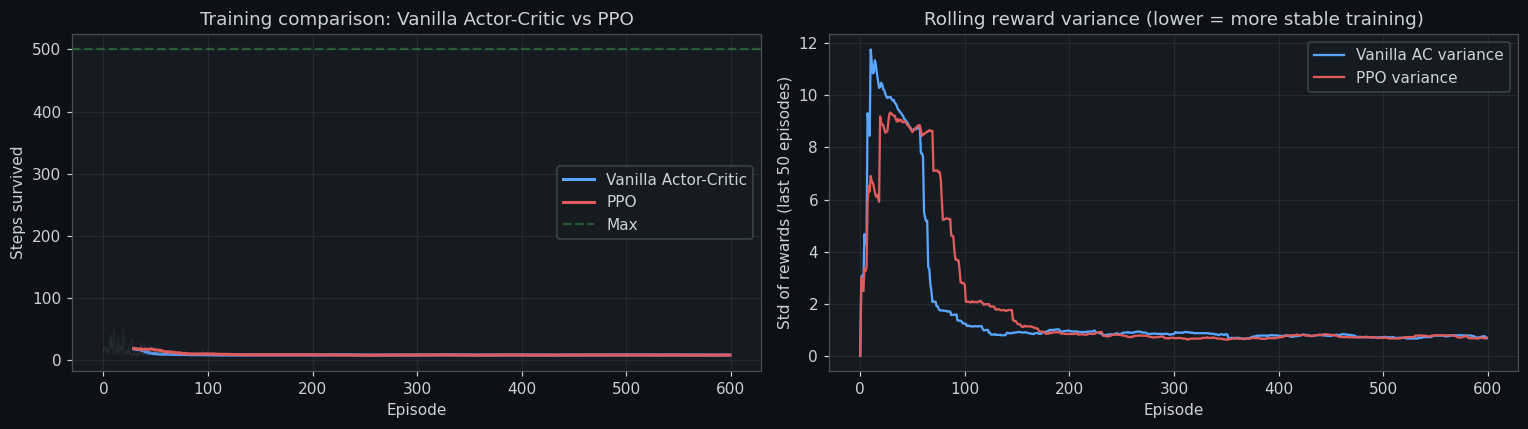

Vanilla AC — final 50 mean: 8.2  std: 0.7
PPO        — final 50 mean: 8.3  std: 0.7


In [11]:
# ── Head-to-head comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

def smooth(arr, w=30):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

ax = axes[0]
ax.plot(rewards_history, color=MUTED, alpha=0.25, linewidth=0.8)
ax.plot(np.arange(29, len(rewards_history)), smooth(rewards_history),
        color=BLUE, linewidth=2, label='Vanilla Actor-Critic')

ax.plot(ppo_rewards, color=MUTED, alpha=0.25, linewidth=0.8)
ax.plot(np.arange(29, len(ppo_rewards)), smooth(ppo_rewards),
        color=ACCENT, linewidth=2, label='PPO')

ax.axhline(500, color=GREEN, linestyle='--', alpha=0.4, label='Max')
ax.set_title('Training comparison: Vanilla Actor-Critic vs PPO', color=TEXT)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps survived')
ax.legend()
ax.grid(True)

# Stability: rolling std of rewards
ax = axes[1]
w = 50
ac_std  = [np.std(rewards_history[max(0,i-w):i+1]) for i in range(len(rewards_history))]
ppo_std = [np.std(ppo_rewards[max(0,i-w):i+1])     for i in range(len(ppo_rewards))]
ax.plot(ac_std,  color=BLUE,   linewidth=1.5, label='Vanilla AC variance')
ax.plot(ppo_std, color=ACCENT, linewidth=1.5, label='PPO variance')
ax.set_title('Rolling reward variance (lower = more stable training)', color=TEXT)
ax.set_xlabel('Episode')
ax.set_ylabel('Std of rewards (last 50 episodes)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Vanilla AC — final 50 mean: {np.mean(rewards_history[-50:]):.1f}  "
      f"std: {np.std(rewards_history[-50:]):.1f}")
print(f"PPO        — final 50 mean: {np.mean(ppo_rewards[-50:]):.1f}  "
      f"std: {np.std(ppo_rewards[-50:]):.1f}")

## Part 8 — The connection back to RLHF

Now the RLHF Stage 3 objective makes complete sense:

$$\max_{\pi_\theta} \; \mathbb{E}\left[ r_\phi(x, y) - \beta \log \frac{\pi_\theta(y|x)}{\pi_{SFT}(y|x)} \right]$$

Map it onto what we've just built:

| RLHF term | Actor-Critic equivalent |
|-----------|------------------------|
| $\pi_\theta$ | Actor (policy network) |
| $r_\phi(x, y)$ | Reward signal (from reward model instead of environment) |
| $\beta \log \frac{\pi_\theta}{\pi_{SFT}}$ | KL penalty — plays the same role as PPO's clip: prevents the policy moving too far |
| Value function | Trained alongside policy; estimates expected reward under current policy |
| Advantage $\hat{A}_t$ | Was this response better or worse than the critic expected? |

The KL penalty and PPO clipping are solving the **same problem** from different directions:
- PPO clips the importance sampling ratio — mechanically prevents large updates
- KL penalty adds a regularisation cost for drifting from a reference — economically discourages large updates

In practice, RLHF uses both: PPO for update stability per batch, KL penalty to keep the policy from straying too far from the SFT model across the entire training run.

### Why this matters for alignment

The value function in RLHF is estimating *how much reward the reward model will give future responses* — not how good those responses actually are. If the reward model has blind spots (which it does, because it was trained on finite noisy human comparisons), the value function learns to exploit those blind spots.

The KL penalty is the only thing standing between the policy and pure reward hacking. The $\beta$ parameter is a dial for how much we trust the reward model: low $\beta$ says "optimise aggressively, the reward model is accurate"; high $\beta$ says "stay close to SFT, the reward model is just a rough proxy".

Every production RLHF system is navigating that tradeoff — and no one has a principled answer for where to set the dial.

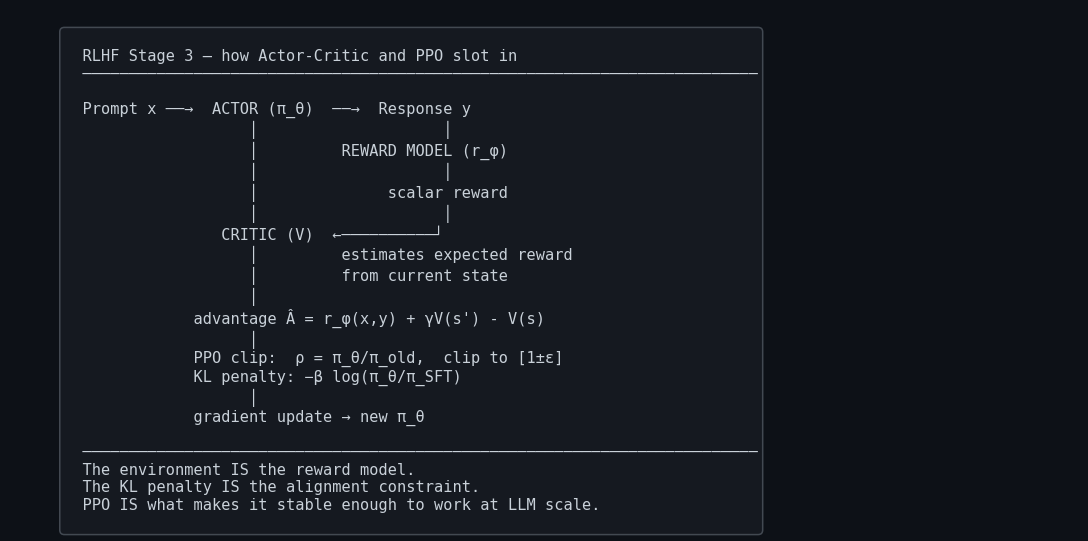

In [12]:
# ── The complete picture ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

diagram = """
  RLHF Stage 3 — how Actor-Critic and PPO slot in
  ─────────────────────────────────────────────────────────────────────────

  Prompt x ──→  ACTOR (π_θ)  ──→  Response y
                    │                    │
                    │         REWARD MODEL (r_φ)
                    │                    │
                    │              scalar reward
                    │                    │
                 CRITIC (V)  ←──────────┘
                    │         estimates expected reward
                    │         from current state
                    │
              advantage Â = r_φ(x,y) + γV(s') - V(s)
                    │
              PPO clip:  ρ = π_θ/π_old,  clip to [1±ε]
              KL penalty: −β log(π_θ/π_SFT)
                    │
              gradient update → new π_θ

  ─────────────────────────────────────────────────────────────────────────
  The environment IS the reward model.
  The KL penalty IS the alignment constraint.
  PPO IS what makes it stable enough to work at LLM scale.
"""

ax.text(0.05, 0.95, diagram, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        fontfamily='monospace', color=TEXT,
        bbox=dict(boxstyle='round', facecolor=SURFACE, edgecolor=MUTED, alpha=0.9))

plt.tight_layout()
plt.show()

## Summary

| Concept | What it is | Why it matters |
|---------|------------|----------------|
| **Value function V(s)** | Expected future reward from state s | Baseline for measuring action quality |
| **TD error / advantage** | $r_t + \gamma V(s_{t+1}) - V(s_t)$ | Was this step better or worse than expected? |
| **Policy gradient** | $\nabla \log \pi(a|s) \cdot \hat{A}$ | Direction to update actor; no env differentiation needed |
| **Actor-Critic** | Policy + value function trained jointly | Reduces variance vs pure policy gradients |
| **Importance sampling ratio** | $\rho = \pi_\theta / \pi_{old}$ | Allows reusing old data safely |
| **PPO clip** | $\min(\rho \hat{A},\ \text{clip}(\rho, 1\pm\epsilon)\hat{A})$ | Prevents destructive updates regardless of gradient size |
| **KL penalty (RLHF)** | $-\beta \log(\pi_\theta / \pi_{SFT})$ | Prevents reward hacking; keeps policy near SFT |

---

### The key equations

**Advantage estimate (TD error):**
$$\boxed{\hat{A}_t = r_t + \gamma V(s_{t+1}) - V(s_t)}$$

**Actor-Critic policy gradient:**
$$\boxed{\nabla_\theta J = \mathbb{E}_t\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot \hat{A}_t\right]}$$

**PPO clipped objective:**
$$\boxed{\mathcal{L}^{CLIP} = \mathbb{E}_t\left[\min\left(\rho_t \hat{A}_t,\ \text{clip}(\rho_t, 1{-}\epsilon, 1{+}\epsilon)\,\hat{A}_t\right)\right]}$$

---

## Things to try

- Set `epsilon=0.0` in PPOAgent — it becomes vanilla Actor-Critic. Compare stability.
- Set `n_epochs=1` in PPOAgent — one pass per batch, no data reuse. How much does performance drop?
- Increase `epsilon` to 0.5 — does training become less stable? Where does it break?
- Add entropy regularisation to the actor loss: $-\lambda \sum_a \pi(a|s)\log\pi(a|s)$. This encourages exploration and often stabilises early training.
- Try `gamma=0.9` vs `gamma=0.999` — how does the discount horizon affect what the agent learns to optimise?